### Load models

In [1]:
from transformers import AutoTokenizer, AutoModelForCausalLM, AutoConfig
from faiss_attn.source.modeling_qwen2 import Qwen2ForCausalLM
import torch
import os
DEVICE = "cuda:0"

MODEL_DIR = "/public/share/model/Qwen3-4B"
model_name = os.path.basename(MODEL_DIR)
tokenizer = AutoTokenizer.from_pretrained(MODEL_DIR, use_fast=True)
tokenizer.pad_token = tokenizer.eos_token
model = Qwen2ForCausalLM.from_pretrained(
    MODEL_DIR, 
    local_files_only=True, 
    device_map=DEVICE, 
    torch_dtype=torch.bfloat16,
    attn_implementation="flash_attention_2",
)
n_layers = model.config.num_hidden_layers
n_heads = model.config.num_attention_heads
n_kv_heads = model.config.num_key_value_heads
model.eval()

`torch_dtype` is deprecated! Use `dtype` instead!
You are using a model of type qwen3 to instantiate a model of type qwen2. This is not supported for all configurations of models and can yield errors.
Qwen2ForCausalLM has generative capabilities, as `prepare_inputs_for_generation` is explicitly defined. However, it doesn't directly inherit from `GenerationMixin`. From 👉v4.50👈 onwards, `PreTrainedModel` will NOT inherit from `GenerationMixin`, and this model will lose the ability to call `generate` and other related functions.
  - If you're using `trust_remote_code=True`, you can get rid of this warning by loading the model with an auto class. See https://huggingface.co/docs/transformers/en/model_doc/auto#auto-classes
  - If you are the owner of the model architecture code, please modify your model class such that it inherits from `GenerationMixin` (after `PreTrainedModel`, otherwise you'll get an exception).
  - If you are not the owner of the model architecture class, please contact t

Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

Qwen2ForCausalLM has generative capabilities, as `prepare_inputs_for_generation` is explicitly defined. However, it doesn't directly inherit from `GenerationMixin`. From 👉v4.50👈 onwards, `PreTrainedModel` will NOT inherit from `GenerationMixin`, and this model will lose the ability to call `generate` and other related functions.
  - If you're using `trust_remote_code=True`, you can get rid of this warning by loading the model with an auto class. See https://huggingface.co/docs/transformers/en/model_doc/auto#auto-classes
  - If you are the owner of the model architecture code, please modify your model class such that it inherits from `GenerationMixin` (after `PreTrainedModel`, otherwise you'll get an exception).
  - If you are not the owner of the model architecture class, please contact the model code owner to update it.
Qwen2ForCausalLM has generative capabilities, as `prepare_inputs_for_generation` is explicitly defined. However, it doesn't directly inherit from `GenerationMixin`. Fr

Qwen2ForCausalLM(
  (model): Qwen2Model(
    (embed_tokens): Embedding(151936, 2560)
    (layers): ModuleList(
      (0-35): 36 x Qwen2DecoderLayer(
        (self_attn): Qwen2FlashAttention2(
          (q_proj): Linear(in_features=2560, out_features=4096, bias=False)
          (k_proj): Linear(in_features=2560, out_features=1024, bias=False)
          (v_proj): Linear(in_features=2560, out_features=1024, bias=False)
          (o_proj): Linear(in_features=4096, out_features=2560, bias=False)
          (rotary_emb): Qwen2RotaryEmbedding()
          (q_norm): Qwen2RMSNorm((128,), eps=1e-06)
          (k_norm): Qwen2RMSNorm((128,), eps=1e-06)
        )
        (mlp): Qwen2MLP(
          (gate_proj): Linear(in_features=2560, out_features=9728, bias=False)
          (up_proj): Linear(in_features=2560, out_features=9728, bias=False)
          (down_proj): Linear(in_features=9728, out_features=2560, bias=False)
          (act_fn): SiLU()
        )
        (input_layernorm): Qwen2RMSNorm((2560,

In [ ]:
# used for highlighting our retrieval heads
retrieval_heads = [
    (22, 23), (22, 22), (13, 12), (7, 6), (20, 24), (22, 21), (24, 23), (29, 14), (16, 21), (2, 31)
]

### 1. Calculating contributions of frequency components

In [3]:
from faiss_attn.source.utils import get_static_attention_kernel_Mm
from tqdm import trange, tqdm
import numpy as np

head_freq_kernels = []
layer_idx = 22
for head_idx in trange(n_heads):
    freq_kernels = []
    head_dim = getattr(model.config, "head_dim", model.config.hidden_size // model.config.num_attention_heads)
    for freq_idx in range(head_dim // 2):
        M_matrix = get_static_attention_kernel_Mm(model, layer_idx, head_idx, distance_n=-32768, m_pair_idx=freq_idx)
        freq_kernels.append(M_matrix)
    head_kernel = torch.stack(freq_kernels, dim=0)  # (num_freqs, H, H)
    head_freq_kernels.append(head_kernel.cpu())
head_freq_kernels = torch.stack(head_freq_kernels, dim=0).cpu().float().numpy()  # (num_heads, num_freqs, H, H)
torch.cuda.empty_cache()
print(head_freq_kernels.shape)

100%|██████████| 32/32 [00:18<00:00,  1.70it/s]


(32, 64, 2560, 2560)


#### Head Frequency Kernel Energy in Certain Layer

100%|██████████| 32/32 [00:42<00:00,  1.34s/it]


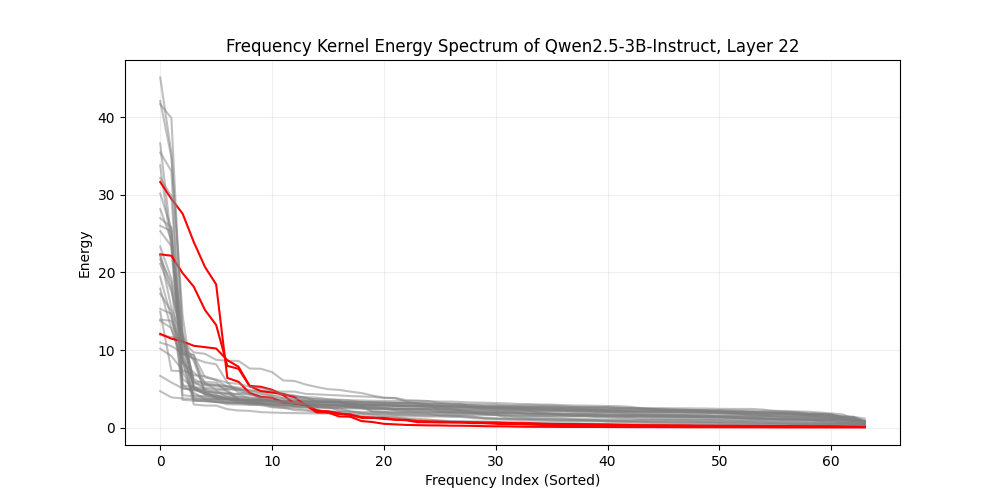

In [ ]:
%matplotlib widget

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import mplcursors

focus = []
# Visualization: Energy Spectrum (replace SVD)
plt.figure(figsize=(10, 5))
lines = []
for head_idx in trange(n_heads):
    norms = (head_freq_kernels[head_idx] ** 2).sum((-1, -2))  # (num_freqs,)
    sorted_norms = np.sort(norms)[::-1]

    # effective rank
    p = norms / (norms.sum() + 1e-12)
    effective_rank = float(np.exp(-np.sum(p * np.log(p + 1e-10))))
    concentration = (p * np.linspace(0, 1, len(norms))).sum()
    score_rank = (concentration ** 1.0) * (1 - effective_rank / len(norms))

    is_retrieval = (layer_idx, head_idx) in retrieval_heads + focus
    line, = plt.plot(sorted_norms, color=("red" if is_retrieval else "gray"), alpha=(1.0 if is_retrieval else 0.5))
    line.set_gid(head_idx)
    line._effective_rank = effective_rank
    line._concentration = concentration
    line._score_rank = score_rank
    lines.append(line)

cursor = mplcursors.cursor(lines, hover=True)

@cursor.connect("add")
def on_add(sel):
    head_idx = sel.artist.get_gid()
    er = getattr(sel.artist, "_effective_rank", float("nan"))
    concentration = getattr(sel.artist, "_concentration", float("nan"))
    score_rank = getattr(sel.artist, "_score_rank", float("nan"))
    sel.annotation.set_text(f"head_idx={head_idx}\neff_rank={er:.2f}\nconcentration={concentration:.4f}\nscore_rank={score_rank:.4f}")

# plt.yscale('log')
plt.title(f"Frequency Kernel Energy Spectrum of Qwen3-4B, Layer {layer_idx}")
plt.xlabel("Frequency Index (Sorted)")
plt.ylabel("Energy")
plt.grid(True, which="both", ls="-", alpha=0.2)
plt.savefig("figs/ska/qwen3-4b-erank.pdf")

Symmetry score

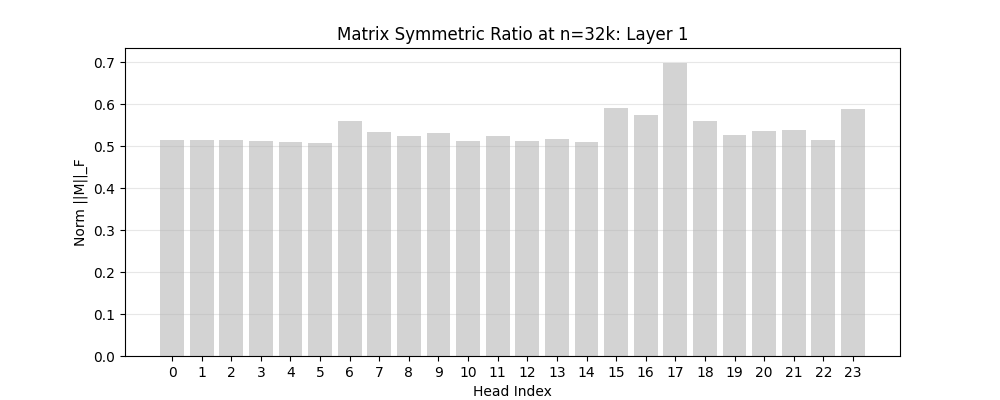

In [ ]:
%matplotlib widget

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import mplcursors

head_kernels = head_freq_kernels.sum(axis=1)  # (n_heads, H, H)
colors = ['red' if (layer_idx, head_idx) in retrieval_heads else 'lightgray' for head_idx in range(n_heads)]
# Visualization: Symmetry of Frequency Kernels
sym_kernels = (head_kernels + head_kernels.transpose(0, 2, 1)) / 2
syms = np.linalg.norm(sym_kernels, axis=(-2, -1)) ** 2 / np.linalg.norm(head_kernels, axis=(-2, -1)) ** 2

plt.figure(figsize=(10, 4))
bars = plt.bar(range(n_heads), syms, color=colors)
plt.title(f"Matrix Symmetric Ratio: Layer {layer_idx}")
plt.xlabel("Head Index")
plt.ylabel("Norm ||M||_F")
plt.xticks(range(n_heads))
plt.grid(axis='y', alpha=0.3)
plt.show()

#### Frequency Kernel Energy Heatmap

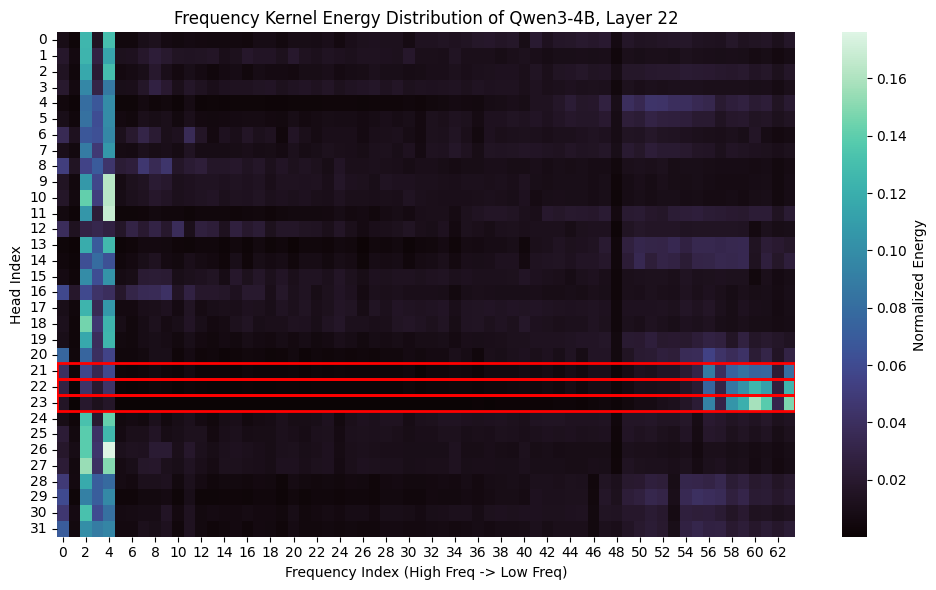

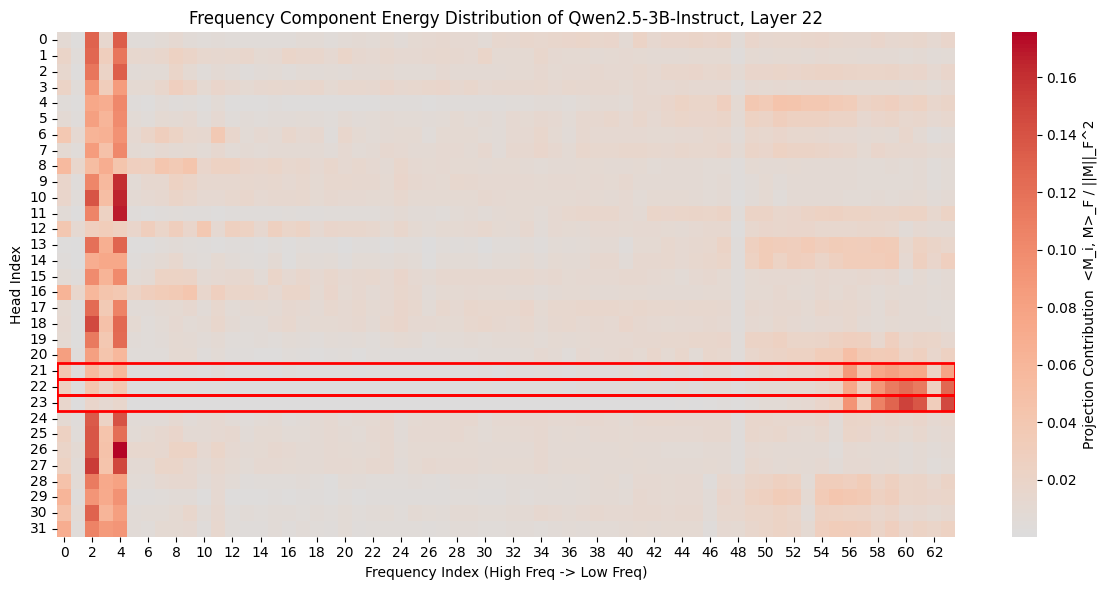

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Visualization 1: RoPE Frequency Energy Distribution (Heatmap)
freq_energy = np.linalg.norm(head_freq_kernels, ord="fro", axis=(-1, -2)) ** 2  # (n_heads, n_freqs)
# Normalize within each head (row-wise)
freq_energy = (freq_energy / (freq_energy.sum(axis=1, keepdims=True) + 1e-12))
plt.figure(figsize=(10, 6))
ax = sns.heatmap(freq_energy, cmap="mako", cbar_kws={'label': 'Normalized Energy'})
plt.title(f"Frequency Kernel Energy Distribution of Qwen3-4B, Layer {layer_idx}")
plt.xlabel("Frequency Index (High Freq -> Low Freq)")
plt.ylabel("Head Index")
for l, h in retrieval_heads:
    if l != layer_idx:
        continue
    ax_hm = plt.gca()
    n_freqs = freq_energy.shape[1]
    ax_hm.add_patch(plt.Rectangle((0, h), n_freqs, 1, fill=False, edgecolor="red", linewidth=2))

plt.tight_layout()
plt.savefig("figs/ska/qwen3-4b-freq-heatmap.pdf")
plt.show()

# Visualization 2: RoPE Frequency Component Contribution to Total Energy
head_kernels = head_freq_kernels.sum(axis=1)
total_energy = np.linalg.norm(head_kernels, ord="fro", axis=(-1, -2)) ** 2 + 1e-12  # (n_heads,)
projections = (head_freq_kernels * head_kernels[:, None, :, :]).sum(axis=(-1, -2))  # (n_heads, n_freqs)
proj_contrib = projections / total_energy[:, None]  # (n_heads, n_freqs)

plt.figure(figsize=(10, 6))
ax = sns.heatmap(
    proj_contrib,
    cmap="coolwarm",
    center=0.0,
    cbar_kws={'label': 'Projection Contribution  <M_i, M>_F / ||M||_F^2'}
)
plt.title(f"Frequency Component Energy Distribution of Qwen3-4B, Layer {layer_idx}")
plt.xlabel("Frequency Index (High Freq -> Low Freq)")
plt.ylabel("Head Index")

# Highlight retrieval heads
for l, h in retrieval_heads:
    if l != layer_idx:
        continue
    ax_hm = plt.gca()
    n_freqs = proj_contrib.shape[1]
    ax_hm.add_patch(plt.Rectangle((0, h), n_freqs, 1, fill=False, edgecolor="red", linewidth=2))

plt.tight_layout()
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

plt.rcParams['axes.unicode_minus'] = False
fig, (ax_line, ax_heat) = plt.subplots(
    nrows=2, ncols=1,
    figsize=(10, 4),
    sharex=True,
    gridspec_kw={'height_ratios': [4, 1]}
)

selected_freqs = [21, 22, 23]
ax_heat = sns.heatmap(freq_energy[selected_freqs], cmap="mako", cbar=False)
ax_heat.set_yticks(np.arange(3) + 0.5)
ax_heat.set_yticklabels(selected_freqs)
ax_heat.set_ylabel('Head Index')
ax_heat.set_title('', fontsize=0)

freq_multiplier = np.concatenate([
    np.linspace(1.0, 1.0, num=8, endpoint=False),
    np.linspace(1.0, 0.2, num=24, endpoint=False),
    np.linspace(0.2, 1.0, num=16, endpoint=False),
    np.linspace(1.0, 1.4, num=8, endpoint=False),
    np.linspace(1.4, 1.0, num=8, endpoint=False),
])

ax_line.axhline(y=1, color='gray', linestyle='--', linewidth=1, alpha=0.7)
ax_line.plot(
    np.arange(64) + 0.5, freq_multiplier, 
    color='#4878d0',
    linestyle='-'
)
ax_line.set_ylabel('Amplification Factor')
ax_line.grid(True, alpha=0.3) 

ax_heat.set_xticks(np.arange(0, 64, 2) + 0.5)
ax_heat.set_xticklabels(np.arange(0, 64, 2), fontsize=10)
ax_heat.set_xlabel('Frequency Index (High Freq -> Low Freq)')

fig.suptitle("Frequency Amplification on Qwen3-4B, Layer 22")
plt.tight_layout()
plt.savefig('figs/multiplier_qwen.pdf', bbox_inches='tight')
plt.show()

### 2. Modify the model

In [2]:
from transformers import AutoTokenizer, AutoModelForCausalLM
from faiss_attn.source.modeling_llama import LlamaForCausalLM
import torch
import os
from torch import nn
DEVICE = "cuda:0"

MODEL_DIR = "/public/share/model/Qwen3-4B"
model_name = os.path.basename(MODEL_DIR)
tokenizer = AutoTokenizer.from_pretrained(MODEL_DIR, use_fast=True)
tokenizer.pad_token = tokenizer.eos_token
modified_model = AutoModelForCausalLM.from_pretrained(
    MODEL_DIR, 
    local_files_only=True, 
    device_map=DEVICE, 
    torch_dtype=torch.bfloat16,
    attn_implementation="flash_attention_2",
)
n_layers = modified_model.config.num_hidden_layers
n_heads = modified_model.config.num_attention_heads
hidden_size = modified_model.config.hidden_size
head_dim = getattr(modified_model.config, "head_dim", hidden_size // n_heads)
modified_model.eval()

`torch_dtype` is deprecated! Use `dtype` instead!


Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

Qwen3ForCausalLM(
  (model): Qwen3Model(
    (embed_tokens): Embedding(151936, 2560)
    (layers): ModuleList(
      (0-35): 36 x Qwen3DecoderLayer(
        (self_attn): Qwen3Attention(
          (q_proj): Linear(in_features=2560, out_features=4096, bias=False)
          (k_proj): Linear(in_features=2560, out_features=1024, bias=False)
          (v_proj): Linear(in_features=2560, out_features=1024, bias=False)
          (o_proj): Linear(in_features=4096, out_features=2560, bias=False)
          (q_norm): Qwen3RMSNorm((128,), eps=1e-06)
          (k_norm): Qwen3RMSNorm((128,), eps=1e-06)
        )
        (mlp): Qwen3MLP(
          (gate_proj): Linear(in_features=2560, out_features=9728, bias=False)
          (up_proj): Linear(in_features=2560, out_features=9728, bias=False)
          (down_proj): Linear(in_features=9728, out_features=2560, bias=False)
          (act_fn): SiLU()
        )
        (input_layernorm): Qwen3RMSNorm((2560,), eps=1e-06)
        (post_attention_layernorm): Qwe

In [ ]:
modified_heads = [
    (22, 23), (22, 22), (13, 12), (7, 6), (20, 24), (22, 21), (24, 23), (29, 14), (16, 21), (2, 31), 
    (13, 15), (29, 12), (24, 20), (21, 8), (24, 22), (20, 21), (20, 26), (9, 30), (19, 24), (13, 13), 
    # (8, 16), (25, 30), (15, 11), (24, 29), (16, 23), (16, 22), (20, 30), (17, 0), (29, 15), (13, 28)
]   # Qwen3-4B
len(modified_heads)

20

#### Modification functions

In [ ]:
from typing import List
import numpy as np

@torch.no_grad()
def modify_q_proj(
    model, 
    layer_idx: int, 
    head_idx_list: List[int], 
    freq_multiplier: np.array,
) -> torch.Tensor:
    # 1. get basic config
    config = model.config
    hidden_size = config.hidden_size
    num_heads = config.num_attention_heads
    head_dim = getattr(config, "head_dim", hidden_size // num_heads)
    
    if freq_multiplier.ndim == 2:
        assert freq_multiplier.shape[0] == len(head_idx_list), f"freq_multiplier first dim {freq_multiplier.shape[0]} does not match head_idx_list length {len(head_idx_list)}"
    if freq_multiplier.shape[-1] != head_dim // 2:
        raise ValueError(f"freq_multiplier length {freq_multiplier.shape[0]} does not match head_dim/2 {head_dim // 2}")

    # 2. get the Attention module of that layer
    if hasattr(model, "model"):
        layers = model.model.layers
    else:
        layers = model.layers

    layer = layers[layer_idx]
    attn = layer.self_attn

    # 3. extract specific rows of W_Q
    # Llama's Linear weight shape is (out_features, in_features)
    # W_Q_all shape: (num_heads * head_dim, hidden_size)
    W_Q_all = torch.clone(attn.q_proj.weight.data)
    for i, head_idx in enumerate(head_idx_list):
        q_start = head_idx * head_dim
        multiplier = freq_multiplier if freq_multiplier.ndim == 1 else freq_multiplier[i]
        # 4. apply the multiplier to the specific rows corresponding to the head_idx
        # x1 = x[..., :half], x2 = x[..., half:]
        half_dim = head_dim // 2
        for m_pair_idx in range(half_dim):
            idx1 = m_pair_idx
            idx2 = m_pair_idx + half_dim
            W_Q_all[[q_start + idx1, q_start + idx2], :] *= multiplier[m_pair_idx]

    return W_Q_all

#### Amplify low-frequency components

In [ ]:
import random
random_heads = [(i, j) for i in range(n_layers) for j in range(n_heads)]
random.shuffle(random_heads)
random_heads = random_heads[:len(modified_heads)]

low, high = 0.2, 1.4
freq_multiplier = np.concatenate([
    np.linspace(1.0, 1.0, num=8),
    np.linspace(1.0, low, num=24),
    np.linspace(low, 1.0, num=16),
    np.linspace(1.0, high, num=8),
    np.linspace(high, 1.0, num=8),
])
for l in range(n_layers):
    heads_to_modify = [h for (layer_h, h) in modified_heads if layer_h == l]
    if len(heads_to_modify) == 0:
        continue
    new_q = modify_q_proj(model, l, heads_to_modify, freq_multiplier)
    modified_model.model.layers[l].self_attn.q_proj.weight.data = new_q

#### Directly remove certain heads

In [ ]:
import random
random_heads = [(i, j) for i in range(n_layers) for j in range(n_heads)]
random.shuffle(random_heads)
random_heads = random_heads[:len(modified_heads)]

for l, h in modified_heads:
    modified_model.model.layers[l].self_attn.o_proj.weight.data[:, h * head_dim : (h + 1) * head_dim].fill_(0)

In [ ]:
tokenizer.save_pretrained("saved_models/Qwen3-4B_top20_enhanced")
modified_model.save_pretrained("saved_models/Qwen3-4B_top20_enhanced")

### 3. Using LPS/lps to detect long-context heads

In [2]:
import torch
import numpy as np
from tqdm import trange, tqdm
from faiss_attn.source.utils import get_static_attention_kernel_Mm

@torch.no_grad()
def calculate_symmetric_with_kernel_func(
    model, 
    check_distance=-65536,
):
    config = model.config
    num_layers = config.num_hidden_layers
    num_heads = config.num_attention_heads
    hidden_size = config.hidden_size
    head_dim = getattr(config, "head_dim", hidden_size // num_heads)
    num_freqs = head_dim // 2
    
    results = {}
    
    print(f"Config: Layers={num_layers}, Heads={num_heads}, Distance={check_distance}")
    
    for layer_idx in trange(num_layers):
        layer_symmetric_scores = []
        for head_idx in range(num_heads):
            M_total = torch.zeros((hidden_size, hidden_size), device=model.device, dtype=torch.float32)
            for m in range(num_freqs):
                M_m = get_static_attention_kernel_Mm(
                    model=model,
                    layer_idx=layer_idx,
                    head_idx=head_idx,
                    distance_n=check_distance,
                    m_pair_idx=m
                )
                M_total += M_m
            symmetric_M = (M_total + M_total.T) / 2.0
            symmetric_score = ((symmetric_M ** 2).sum() / ((M_total ** 2).sum() + 1e-9) - 0.5).abs().item()
            layer_symmetric_scores.append(symmetric_score)
        
        layer_symmetric_scores = np.array(layer_symmetric_scores)
        for h in range(num_heads):
            results[(layer_idx, h)] = layer_symmetric_scores[h]
    del M_m
    return {key: results[key] for key in sorted(results.keys(), key=lambda x: results[x], reverse=True)}


@torch.no_grad()
def calculate_lps_with_kernel_func(
    model, 
    check_distance=-65536,
    layer_normalize: bool = False,
    alpha: float=0.4,
):
    config = model.config
    num_layers = config.num_hidden_layers
    num_heads = config.num_attention_heads
    hidden_size = config.hidden_size
    head_dim = getattr(config, "head_dim", hidden_size // num_heads)
    num_freqs = head_dim // 2
    
    results = {}
    
    print(f"Config: Layers={num_layers}, Heads={num_heads}, Distance={check_distance}")
    
    for layer_idx in trange(num_layers):
        layer_energy_scores = []
        layer_erank_scores = []
        for head_idx in range(num_heads):
            freq_energies = []
            for m in range(num_freqs):
                M_m = get_static_attention_kernel_Mm(
                    model=model,
                    layer_idx=layer_idx,
                    head_idx=head_idx,
                    distance_n=check_distance,
                    m_pair_idx=m
                )
                # Calculate the energy of the components (Frobenius norm squared)
                m_energy = (M_m ** 2).sum().item()
                freq_energies.append(m_energy)
            freq_energies = np.array(freq_energies)

            if freq_energies.max() > 1e-9:
                # 1. Calculate effective rank
                probs = freq_energies / freq_energies.sum()
                effective_rank = np.exp(-(probs * np.log(probs + 1e-10)).sum())
                score_erank = 1 - effective_rank / len(probs)
                # 2. Calculate weighted energy ratio, with higher weights for lower frequencies
                score_energy = (probs * np.linspace(0, 1, len(probs))).sum()
            else:
                score_erank = 0.0
                score_energy = 0.0
            layer_erank_scores.append(score_erank)
            layer_energy_scores.append(score_energy)
        
        layer_energy_scores = np.array(layer_energy_scores)
        layer_erank_scores = np.array(layer_erank_scores)
        lps_scores = (layer_energy_scores ** alpha) * (layer_erank_scores ** (1 - alpha))
        normalized_scores = (lps_scores - lps_scores.mean()) / (lps_scores.std() + 1e-6)
        for h in range(num_heads):
            final_lps = lps_scores[h]
            results[(layer_idx, h)] = {
                "lps_score": final_lps,
                "normalized_lps_score": normalized_scores[h],
                "raw_energy": layer_energy_scores[h],
                "raw_erank": layer_erank_scores[h]
            }
    del M_m
    k = "lps_score" if not layer_normalize else "normalized_lps_score"
    return {key: results[key] for key in sorted(results.keys(), key=lambda x: results[x][k], reverse=True)}

In [3]:
lps_results = calculate_lps_with_kernel_func(model, check_distance=-32768, layer_normalize=False)
sym_results = calculate_symmetric_with_kernel_func(model, check_distance=-32768)

Config: Layers=36, Heads=32, Distance=-32768


100%|██████████| 36/36 [00:26<00:00,  1.35it/s]


Config: Layers=36, Heads=32, Distance=-32768


100%|██████████| 36/36 [00:20<00:00,  1.72it/s]


In [ ]:
lps_orig = lps_results
lps_amp = calculate_lps_with_kernel_func(modified_model, check_distance=-32768, layer_normalize=False)

Config: Layers=36, Heads=32, Distance=-32768


100%|██████████| 36/36 [00:25<00:00,  1.41it/s]


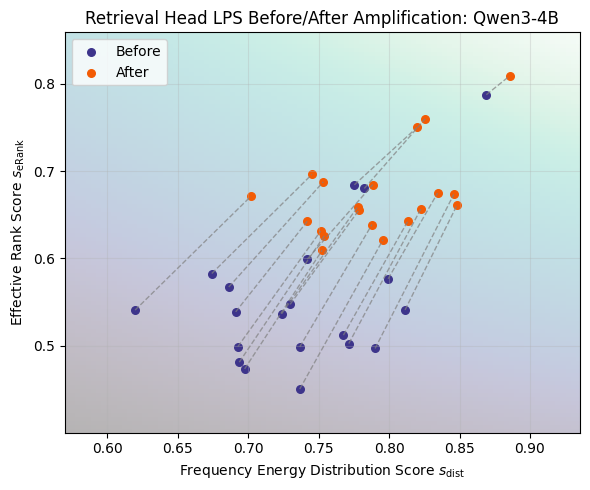

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(6, 5))
all_x = [lps_orig[k]["raw_energy"] for k in modified_heads] + [lps_amp[k]["raw_energy"] for k in modified_heads]
all_y = [lps_orig[k]["raw_erank"] for k in modified_heads] + [lps_amp[k]["raw_erank"] for k in modified_heads]
x_min, x_max = np.min(all_x) - 0.05, np.max(all_x) + 0.05
y_min, y_max = np.min(all_y) - 0.05, np.max(all_y) + 0.05

x_grid, y_grid = np.meshgrid(np.linspace(x_min, x_max, 100), np.linspace(y_min, y_max, 100))
product_grid = (x_grid ** 0.4) * (y_grid ** 0.6)
# larger product produce brighter background color, indicating higher LPS score regions
plt.imshow(product_grid, extent=[x_min, x_max, y_min, y_max], origin="lower",
           cmap="mako", alpha=0.3, aspect="auto")

for k in modified_heads:
    x_orig, y_orig = lps_orig[k]["raw_energy"], lps_orig[k]["raw_erank"]
    x_amp, y_amp = lps_amp[k]["raw_energy"], lps_amp[k]["raw_erank"]
    plt.plot([x_orig, x_amp], [y_orig, y_amp], color="gray", linestyle="--", linewidth=1, alpha=0.7)
    plt.scatter(x_orig, y_orig, color="#3d348b", s=30, label="Before" if k == modified_heads[0] else "")
    plt.scatter(x_amp, y_amp, color="#f35b04", s=30, label="After" if k == modified_heads[0] else "")
    
plt.xlabel("Frequency Energy Distribution Score $s_\mathrm{dist}$")
plt.ylabel("Effective Rank Score $s_\mathrm{eRank}$")
plt.title("Retrieval Head LPS Before/After Amplification: Qwen3-4B")
plt.grid(True, alpha=0.3)
plt.legend(loc="best")
plt.xlim(x_min, x_max)
plt.ylim(y_min, y_max)

plt.tight_layout()
plt.savefig("figs/lps_amp_qwen3.pdf", bbox_inches="tight")
plt.show()

In [4]:
sym_penalty = 0.5
final_scores = {k: lps_results[k]["lps_score"] - sym_penalty * sym_results[k] for k in sorted(lps_results.keys(), key=lambda x: lps_results[x]["lps_score"] - sym_penalty * sym_results[x], reverse=True)}
print([k for k in list(final_scores.keys())[:30]])

[(22, 23), (22, 22), (13, 12), (7, 6), (20, 24), (22, 21), (24, 23), (29, 14), (16, 21), (2, 31), (13, 15), (29, 12), (24, 20), (21, 8), (24, 22), (20, 21), (20, 26), (9, 30), (19, 24), (13, 13), (8, 16), (25, 30), (15, 11), (24, 29), (16, 23), (16, 22), (20, 30), (17, 0), (29, 15), (13, 28)]


### 4. Run on actual long context

In [ ]:
# build needle-in-a-haystack evaluation context
from faiss_attn.source.utils import NIAHBuilder
context_builder = NIAHBuilder(tokenizer=tokenizer, haystack_dir="PaulGrahamEssays")

In [16]:
needle = "The best thing to do in San Francisco is eat a sandwich and sit in Dolores Park on a sunny day."
question = "What is the best thing to do in San Francisco?"
# question = "What did Mr. Smith say in Chaoyang Garden?"
input_str = context_builder.generate_context(context_len=30000, depth_ratio=0.2, needle_str=needle, question_str=question, enable_thinking=False)
input_str += "The best thing to do in San Francisco is"
# input_str += "Mr. Smith said in Chaoyang Garden that"
real_needle = "eat a sandwich and sit in Dolores Park on a sunny day."
print(input_str[-500:])

 it's
strange to describe Lisp in terms of its
variation from the random expedients other languages
adopted.  That was not, probably, how McCarthy
thought of it.  Lisp wasn't designed to fix the mistakes
in Fortran; it came about more as the byproduct of an
attempt to axiomatize computation.December 2</book>
Based on the content of the book, Question: What is the best thing to do in San Francisco?
Answer:<|im_end|>
<|im_start|>assistant
<think>

</think>

The best thing to do in San Francisco is


In [15]:
del outputs, outputs_prefill, past_kv, softmax_attn_weights, attn_weights, topk_values, topk_indices, pair_attn_weights, pair_topk_indices, pair_topk_values, x_i_query, x_j_key
torch.cuda.empty_cache()

In [ ]:
import torch
import pandas as pd
import math

print("[Needle]", real_needle)
layer_idx = 22
with torch.no_grad():
    input_ids = tokenizer(input_str, return_tensors="pt", add_special_tokens=False).input_ids.to(DEVICE)
    print("Input length:", input_ids.shape[1])
    outputs_prefill = model(input_ids=input_ids[:,:-1], use_cache=True, return_dict=True)
    past_kv = outputs_prefill.past_key_values
    outputs = model(input_ids=input_ids[:,-1:], past_key_values=past_kv, use_cache=True, output_attentions=True, attn_mode="torch")
top_token_ids = outputs.logits[0, -1].topk(5)
print("Top predicted tokens for the next position:")
for score, token_id in zip(top_token_ids.values, top_token_ids.indices):
    token_str = tokenizer.decode(token_id.unsqueeze(0), skip_special_tokens=False)
    print(f"['{token_str}' {score.item():.4f}]", end=' ')

x_i_query = outputs["inspect"][layer_idx]["query"]      # (bsz=1, n_heads, seq_len=1, head_dim)
x_j_key = outputs["inspect"][layer_idx]["key"]      # (bsz=1, n_heads, seq_len, head_dim)
head_dim = x_i_query.shape[-1]
attn_weights = torch.matmul(x_i_query, x_j_key.transpose(2, 3))[0, :, 0] / math.sqrt(head_dim)  # 未归一化，(num_heads, seq_len)
softmax_attn_weights = outputs.attentions[layer_idx]  # (batch_size=1, num_heads, seq_len, seq_len)
softmax_attn_weights = softmax_attn_weights[0, :, -1, :]  # (num_heads, seq_len)
topk_values, topk_indices = torch.topk(softmax_attn_weights, k=10, dim=-1)  # (num_heads, k)

x_i_query = torch.stack(
    (x_i_query[..., :x_i_query.shape[-1]//2], x_i_query[..., x_i_query.shape[-1]//2:]), dim=-1
).transpose(2, 3)    # (bsz=1, n_heads, n_head_dim_pairs, seq_len=1, 2)
x_j_key = torch.stack(
    (x_j_key[..., :x_j_key.shape[-1]//2], x_j_key[..., x_j_key.shape[-1]//2:]), dim=-1
).transpose(2, 3)    # (bsz=1, n_heads, n_head_dim_pairs, seq_len, 2)
pair_attn_weights = torch.matmul(x_i_query, x_j_key.transpose(3, 4)) / math.sqrt(head_dim)  # (bsz=1, n_heads, n_head_dim_pairs, seq_len=1, seq_len)

pair_attn_weights = pair_attn_weights[0, :, :, 0, :]  # (n_heads, n_head_dim_pairs, seq_len)
pair_topk_values, pair_topk_indices = torch.topk(pair_attn_weights, k=10, dim=-1)  # (n_heads, n_head_dim_pairs, k)
pair_indexed_values = pair_attn_weights.gather(-1, pair_topk_indices)  # (n_heads, n_head_dim_pairs, k)

def emphasize_if_in_needle(tok: str) -> str:
    disp = tok.replace("\n", "\\n")
    if tok.strip() and (tok.strip() in real_needle):
        return f"<b><span style='background-color:#ff4d4f;color:white;padding:1px 4px;border-radius:4px'>{disp}</span></b>"
    return disp
from IPython.display import display, HTML
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", None)
pd.set_option("display.width", None)

[Needle] eat a sandwich and sit in Dolores Park on a sunny day.
Input length: 29849
Top predicted tokens for the next position:
[' to' 42.5000] [' eat' 40.5000] [' eating' 27.6250] [' **' 25.8750] [' Eat' 25.7500] 

In [ ]:
def emphasize_if_in_needle(tok: str) -> str:
    disp = tok.replace("\n", "\\n")
    if tok.strip() and (tok.strip() in real_needle):
        return f"<b><span style='background-color:#ff4d4f;color:white;padding:1px 4px;border-radius:4px'>{disp}</span></b>"
    elif tok.strip() and (tok.strip() == "<|begin_of_text|>" or tok.strip() == "<|im_start|>"):
        return f"<b><span style='background-color:#1890ff;color:white;padding:1px 4px;border-radius:4px'>{disp}</span></b>"
    return disp

rows = []
for head_idx in range(n_heads):
    row = {
        "layer": layer_idx,
        "head": head_idx,
    }
    for r in range(topk_indices.shape[1]):
        token_pos = int(topk_indices[head_idx, r].item())
        tok_str = tokenizer.decode(input_ids[0, token_pos:token_pos + 1], skip_special_tokens=False)

        row[f"token#{r+1}"] = emphasize_if_in_needle(tok_str)
        row[f"attn#{r+1}"] = f"{topk_values[head_idx, r].item():.4f}"
        row[f"pos#{r+1}"] = token_pos
    rows.append(row)

df_attn = pd.DataFrame(rows, index=None)
display(HTML(df_attn.to_html(escape=False, index=False)))

layer,head,token#1,attn#1,pos#1,token#2,attn#2,pos#2,token#3,attn#3,pos#3,token#4,attn#4,pos#4,token#5,attn#5,pos#5,token#6,attn#6,pos#6,token#7,attn#7,pos#7,token#8,attn#8,pos#8,token#9,attn#9,pos#9,token#10,attn#10,pos#10
22,0,San,0.0889,29826,Dol,0.0610,5969,to,0.0447,29843,The,0.0347,29840,on,0.0254,5972,in,0.0254,29825,haven,0.0211,5785,won,0.0187,515,haven,0.0165,15967,to,0.0165,29823
22,1,San,0.0977,29826,The,0.0918,29840,do,0.0762,29844,in,0.0669,29845,<|im_start|>,0.0522,0,haven,0.0491,5785,thing,0.0491,29842,is,0.0432,29848,haven,0.0432,15967,won,0.0408,515
22,2,The,0.0762,29840,<|im_start|>,0.0674,0,is,0.0525,29848,haven,0.0493,5785,won,0.0435,515,to,0.0361,29843,San,0.0339,29826,haven,0.0339,15967,?\n,0.0339,29828,do,0.0248,29844
22,3,haven,0.0723,5785,haven,0.0679,15967,<|im_start|>,0.0679,0,won,0.0635,515,,0.0364,19168,didn,0.0364,23112,doesn,0.0342,26338,Francisco,0.0342,29847,didn,0.0320,8759,thing,0.0249,29842
22,4,is,0.1001,5962,and,0.0884,5966,day,0.0830,5975,eat,0.0569,5963,on,0.0417,5972,sandwich,0.0417,5965,do,0.0347,5958,is,0.0347,29848,Park,0.0347,5971,do,0.0238,29844
22,5,haven,0.0933,15967,doesn,0.0820,26338,<|im_start|>,0.0820,0,didn,0.0601,23112,,0.0530,19168,Francisco,0.0530,29827,haven,0.0469,5785,do,0.0469,29844,didn,0.0388,8759,won,0.0322,515
22,6,is,0.1865,29848,Francisco,0.0569,29827,best,0.0325,29841,thing,0.0305,29842,The,0.0305,29840,San,0.0305,29826,in,0.0223,29845,in,0.0210,29825,:,0.0197,29830,do,0.0197,29844
22,7,do,0.2100,29844,thing,0.1270,29842,?\n,0.1123,29828,best,0.0684,29841,in,0.0469,29825,in,0.0469,29845,San,0.0413,29826,Francisco,0.0303,29827,to,0.0267,29823,do,0.0221,29824
22,8,is,0.5156,29848,do,0.0618,29844,thing,0.0452,29842,San,0.0425,29846,in,0.0398,29845,best,0.0275,29841,to,0.0227,29843,The,0.0188,29840,?\n,0.0188,29828,Francisco,0.0156,29827
22,9,is,0.0674,29848,to,0.0635,29843,San,0.0559,29826,\n\n,0.0525,29839,<|im_start|>,0.0493,0,?\n,0.0493,29828,:,0.0410,29830,won,0.0349,515,The,0.0349,29840,thing,0.0339,29842


In [ ]:
# for a certain head top-10 attended tokens, show the attention contribution of each frequency
head_idx = 23
topk_token_indices = topk_indices[head_idx]  # (k,)
indexed_pair_topk_values = pair_attn_weights[head_idx, :, topk_token_indices]  # (n_head_dim_pairs, k)
rows = []
for dim_pair_idx in range(head_dim // 2):
    row = {
        "layer": layer_idx,
        "head": head_idx,
        "dim": dim_pair_idx,
    }
    ranked_pair_attn_weights = torch.argsort(pair_attn_weights[head_idx, dim_pair_idx], descending=True)
    sorted_indices = torch.argsort(indexed_pair_topk_values[dim_pair_idx], descending=True)
    for r, i in enumerate(sorted_indices):
        token_pos = int(topk_token_indices[i].item())
        tok_str = tokenizer.decode(input_ids[0, token_pos:token_pos + 1], skip_special_tokens=False)
        relative_attn = indexed_pair_topk_values[dim_pair_idx, i].item()
        # relative_attn = pair_topk_values[head_idx, dim_pair_idx, r].item() - pair_attn_weights[head_idx, dim_pair_idx].item()
        # relative_attn = pair_topk_values[head_idx, dim_pair_idx, r].item() - softmax_attn_weights[head_idx, r].item()

        row[f"token#{r+1}"] = emphasize_if_in_needle(tok_str)
        row[f"rank#{r+1}"] = (ranked_pair_attn_weights == token_pos).nonzero(as_tuple=False).item()     # 获取名次
        row[f"attn#{r+1}"] = f"{relative_attn:.4f}"
        row[f"pos#{r+1}"] = token_pos
    rows.append(row)

df_attn = pd.DataFrame(rows, index=None)
display(HTML(df_attn.to_html(escape=False, index=False)))

layer,head,dim,token#1,rank#1,attn#1,pos#1,token#2,rank#2,attn#2,pos#2,token#3,rank#3,attn#3,pos#3,token#4,rank#4,attn#4,pos#4,token#5,rank#5,attn#5,pos#5,token#6,rank#6,attn#6,pos#6,token#7,rank#7,attn#7,pos#7,token#8,rank#8,attn#8,pos#8,token#9,rank#9,attn#9,pos#9,token#10,rank#10,attn#10,pos#10
22,23,0,to,143,0.0801,16613,that,461,0.0640,5575,writing,1936,0.0403,8069,eat,2357,0.0369,5963,just,9496,0.0081,15509,a,17845,-0.0037,6256,<|im_start|>,19945,-0.0076,0,\n,21122,-0.0103,17665,the,22340,-0.0135,21661,taking,26725,-0.0317,1116
22,23,1,the,4248,0.0109,21661,a,6025,0.0086,6256,that,13115,0.0017,5575,\n,13600,0.0013,17665,<|im_start|>,17183,-0.0019,0,taking,18662,-0.0032,1116,just,20637,-0.0051,15509,writing,23051,-0.0076,8069,eat,24577,-0.0094,5963,to,25394,-0.0105,16613
22,23,2,\n,1601,0.0016,17665,the,2827,0.0012,21661,that,5687,0.0007,5575,to,10782,0.0002,16613,taking,14936,-0.0000,1116,<|im_start|>,18088,-0.0002,0,just,19880,-0.0003,15509,writing,23259,-0.0006,8069,a,24594,-0.0008,6256,eat,27023,-0.0013,5963
22,23,3,\n,3737,0.0056,17665,eat,4704,0.0047,5963,the,9087,0.0019,21661,that,14350,0.0001,5575,<|im_start|>,14835,0.0000,0,taking,18655,-0.0010,1116,a,20441,-0.0017,6256,writing,25712,-0.0052,8069,just,26383,-0.0059,15509,to,26542,-0.0060,16613
22,23,4,eat,1471,0.0002,5963,that,4409,0.0001,5575,writing,8335,0.0001,8069,<|im_start|>,14932,0.0000,0,a,17599,-0.0000,6256,to,19255,-0.0000,16613,\n,20005,-0.0000,17665,taking,20048,-0.0000,1116,just,20337,-0.0000,15509,the,21982,-0.0001,21661
22,23,5,just,3115,0.0069,15509,to,13510,0.0007,16613,<|im_start|>,14274,0.0003,0,taking,18038,-0.0015,1116,the,18786,-0.0019,21661,that,20786,-0.0030,5575,a,24332,-0.0050,6256,\n,28705,-0.0093,17665,eat,29406,-0.0111,5963,writing,29559,-0.0118,8069
22,23,6,that,22,0.0608,5575,eat,2071,0.0332,5963,just,3702,0.0270,15509,to,5329,0.0221,16613,\n,6248,0.0197,17665,a,9004,0.0131,6256,writing,13838,0.0023,8069,<|im_start|>,14483,0.0009,0,taking,17891,-0.0066,1116,the,22780,-0.0175,21661
22,23,7,taking,6525,0.0068,1116,\n,10796,0.0029,17665,eat,12636,0.0015,5963,<|im_start|>,13953,0.0007,0,that,16604,-0.0011,5575,to,16620,-0.0011,16613,the,18714,-0.0026,21661,writing,22376,-0.0059,8069,just,23050,-0.0066,15509,a,23521,-0.0072,6256
22,23,8,writing,8594,0.0032,8069,eat,10142,0.0022,5963,taking,11234,0.0016,1116,to,14141,0.0003,16613,<|im_start|>,16602,-0.0005,0,a,21768,-0.0036,6256,that,21874,-0.0037,5575,the,22689,-0.0043,21661,just,24703,-0.0061,15509,\n,26097,-0.0077,17665
22,23,9,that,447,0.0292,5575,writing,4436,0.0133,8069,eat,4816,0.0126,5963,the,6909,0.0092,21661,to,10667,0.0045,16613,\n,10922,0.0043,17665,<|im_start|>,14836,0.0001,0,taking,17623,-0.0028,1116,a,22554,-0.0085,6256,just,23689,-0.0101,15509


In [ ]:
del outputs, outputs_prefill, past_kv, softmax_attn_weights, attn_weights, topk_values, topk_indices, pair_topk_indices, pair_topk_values
torch.cuda.empty_cache()